# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Data import

In [2]:
longtitude = []
latitude = []
height = []
with open("channel_data.txt", "r") as f:
    for line in f:
        data = line.split()
        latitude.append(float(data[0]))
        longtitude.append(float(data[1]))
        height.append(int(data[2]))
longtitude = np.array(longtitude)
latitude = np.array(latitude)
height = np.array(height)

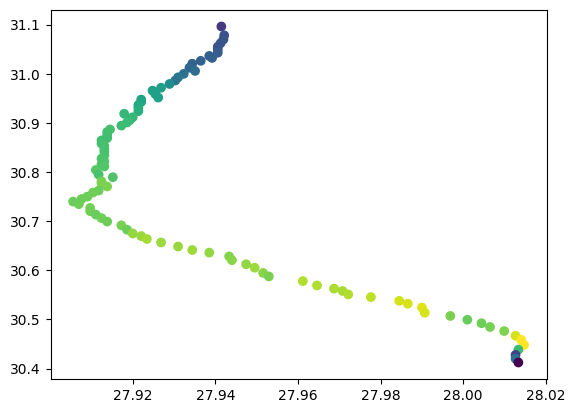

In [3]:
plt.scatter(longtitude, latitude, c=height, cmap="viridis")

# Problem 2

In [4]:
# Function to calculate the distance between two points on the Earth using the Haversine formula
def haversine_np(lat1, lon1, lat2, lon2, radius=6371000):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return radius * c

In [5]:
distanceFromZero = [0]
for i in range(1, len(longtitude)):
    # append distance in meter from (0,0) to (longtitude[i], latitude[i])
    distanceFromZero.append(haversine_np(latitude[0], longtitude[0], latitude[i], longtitude[i]))
distanceFromZero = np.array(distanceFromZero)

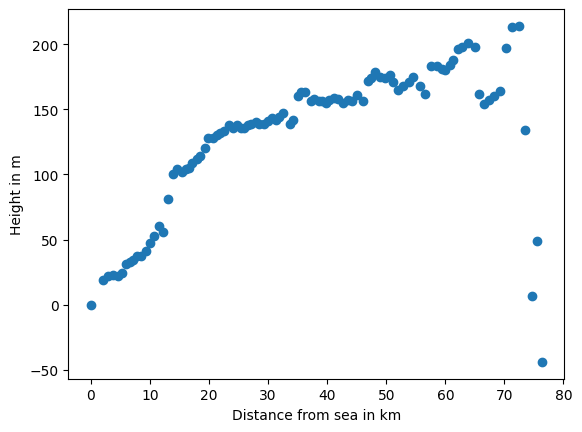

In [6]:
plt.figure()
plt.scatter(distanceFromZero/1000, height)
plt.xlabel("Distance from sea in km")
plt.ylabel("Height in m")
plt.show()

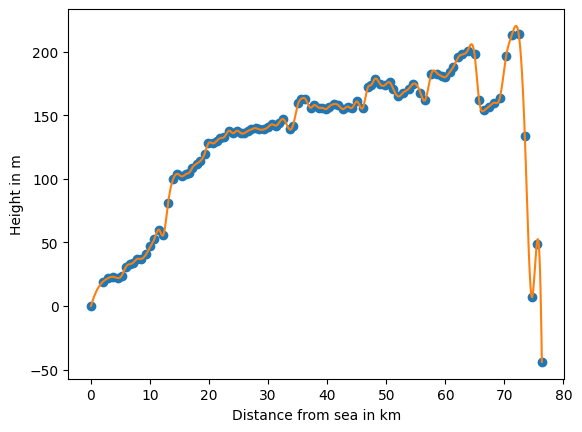

In [7]:
# interpolate the height
interpolator = interp1d(distanceFromZero, height, kind="cubic")
x = np.linspace(0, distanceFromZero[-1], 1000)
y = interpolator(x)
plt.figure()
plt.plot(distanceFromZero/1000, height, "o", label="Data points")
plt.plot(x/1000, y)
plt.xlabel("Distance from sea in km")
plt.ylabel("Height in m")
plt.show()

In [8]:
dist = 250
with open("heights.txt", "w") as f:
    for i in range(0, int(np.floor(distanceFromZero[-1])), dist):
        print(interpolator(i).flatten()[0], file=f)

# Problem 3

In [28]:
from collections import Counter
def get_incremental_nukes(nukesX, nukesY):
    #nukesX = distance from sea in m
    #nukesY = height in m 

    incremental_nukesX = set( [ (nukesX[i] - nukesX[i-1], int(nukesY[i]))  for i in range(1, len(nukesX)) ]) 


    return incremental_nukesX 


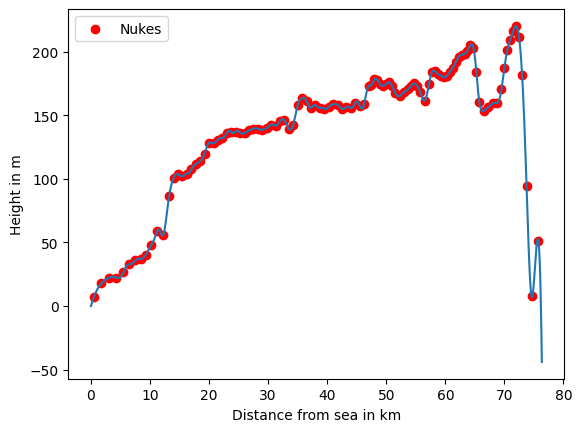

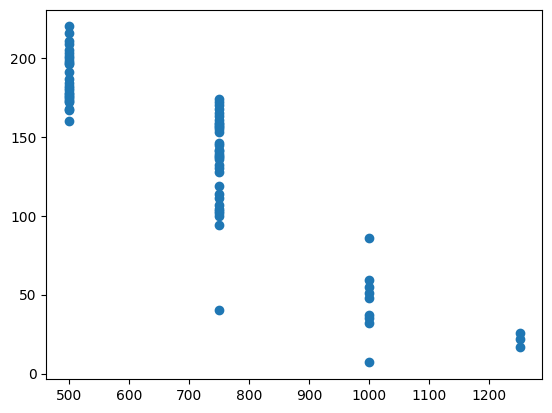

In [32]:
objVal = 108
nukes = [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0]
nukesX = []
nukesY = []
for i in range(len(nukes)):
    if nukes[i] == 1.0:
        nukesX.append(i * dist)
        nukesY.append(interpolator(i * dist).flatten()[0])
nukesX = np.array(nukesX)
nukesY = np.array(nukesY)
        
plt.figure()
plt.plot(x/1000, y)
plt.scatter(nukesX/1000, nukesY, color="red", label="Nukes")
plt.xlabel("Distance from sea in km")
plt.ylabel("Height in m")
plt.legend()
plt.show()

s = get_incremental_nukes(nukesX, nukesY)
#Plot order the incremental nukes by distance from sea and height 
s = sorted(s, key=lambda x: (x[0], x[1]))
incremental_nukesX = [x[0] for x in s]
incremental_nukesY = [x[1] for x in s]
plt.scatter(incremental_nukesX, incremental_nukesY)

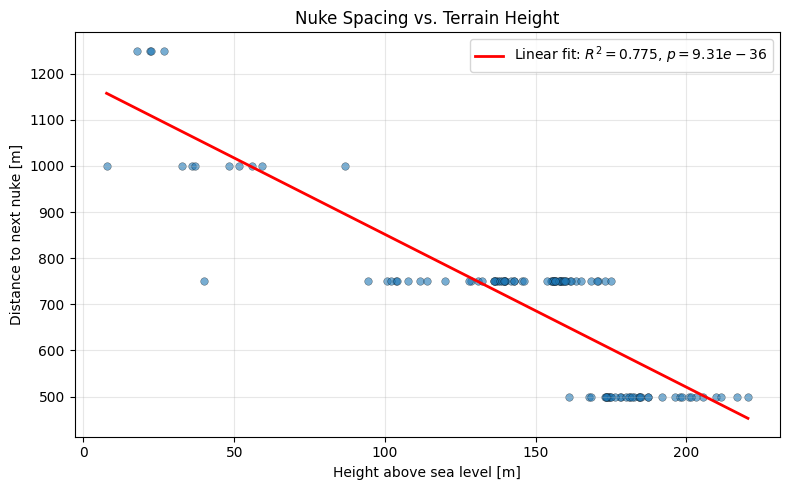

Slope:     -3.3129 m/m
Intercept: 1183.04 m
R²:        0.7747
p-value:   9.31e-36


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def plot_nuke_spacing_vs_height(nukesX, nukesY):
    nukesX = np.array(nukesX)
    nukesY = np.array(nukesY)

    # Compute spacing between consecutive nukes
    spacing = np.diff(nukesX)
    heights = nukesY[1:]  # height at the second point of each pair

    # Linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(heights, spacing)
    x_fit = np.linspace(heights.min(), heights.max(), 100)
    y_fit = slope * x_fit + intercept

    # Plot
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(heights, spacing, alpha=0.6, edgecolors='k', linewidths=0.3, s=30)
    ax.plot(x_fit, y_fit, 'r-', linewidth=2,
            label=f'Linear fit: $R^2 = {r_value**2:.3f}$, $p = {p_value:.2e}$')

    ax.set_xlabel('Height above sea level [m]')
    ax.set_ylabel('Distance to next nuke [m]')
    ax.set_title('Nuke Spacing vs. Terrain Height')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('nuke_spacing_vs_height.png', dpi=150)
    plt.show()

    print(f"Slope:     {slope:.4f} m/m")
    print(f"Intercept: {intercept:.2f} m")
    print(f"R²:        {r_value**2:.4f}")
    print(f"p-value:   {p_value:.2e}")

plot_nuke_spacing_vs_height(nukesX, nukesY)

In [11]:
neightbor = False 

for i in range(1, len(nukes)):
    if nukes[i] == 1.0 and nukes[i-1] == 1.0:
        neightbor = True
        break 

print("Is there any neighbor nukes?", neightbor)


Is there any neighbor nukes? False


# Problem 4

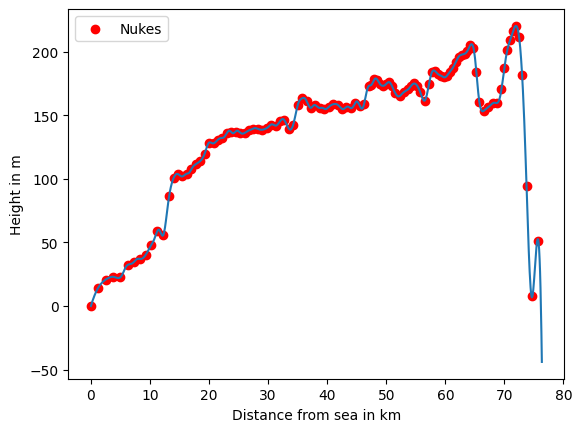

Is there any neighbor nukes? False


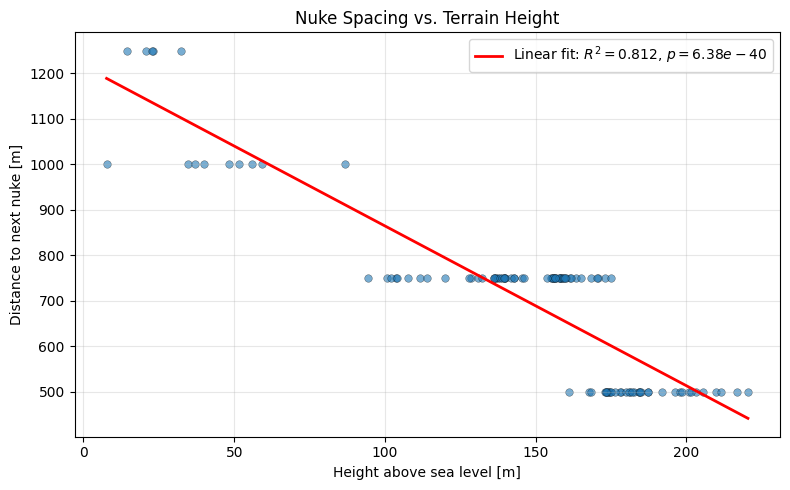

Slope:     -3.5109 m/m
Intercept: 1216.07 m
R²:        0.8122
p-value:   6.38e-40


In [34]:
objVal = 27934
nukes = [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0]
nukesX = []
nukesY = []
for i in range(len(nukes)):
    if nukes[i] == 1.0:
        nukesX.append(i * dist)
        nukesY.append(interpolator(i * dist).flatten()[0])
nukesX = np.array(nukesX)
nukesY = np.array(nukesY)
        
plt.figure()
plt.plot(x/1000, y)
plt.scatter(nukesX/1000, nukesY, color="red", label="Nukes")
plt.xlabel("Distance from sea in km")
plt.ylabel("Height in m")
plt.legend()
plt.show()

neightbor = False 

for i in range(1, len(nukes)):
    if nukes[i] == 1.0 and nukes[i-1] == 1.0:
        neightbor = True
        break 

print("Is there any neighbor nukes?", neightbor)

plot_nuke_spacing_vs_height(nukesX, nukesY)


# Problem 5

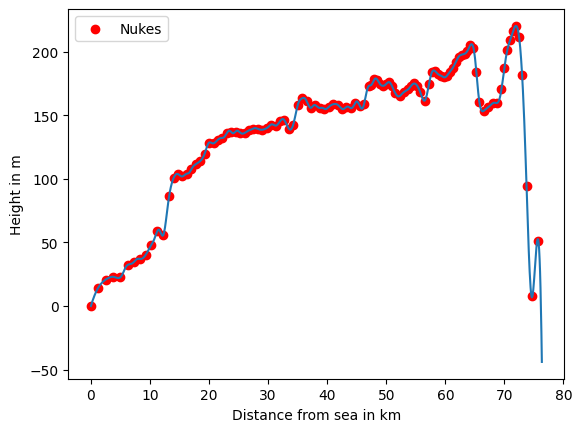

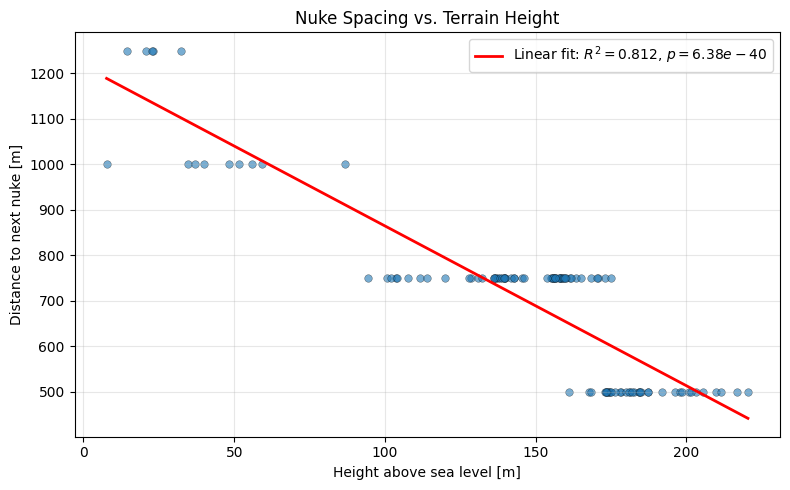

Slope:     -3.5109 m/m
Intercept: 1216.07 m
R²:        0.8122
p-value:   6.38e-40


In [35]:
objVal = 27934
nukes = [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0]
nukesX = []
nukesY = []
for i in range(len(nukes)):
    if nukes[i] == 1.0:
        nukesX.append(i * dist)
        nukesY.append(interpolator(i * dist).flatten()[0])
nukesX = np.array(nukesX)
nukesY = np.array(nukesY)
        
plt.figure()
plt.plot(x/1000, y)
plt.scatter(nukesX/1000, nukesY, color="red", label="Nukes")
plt.xlabel("Distance from sea in km")
plt.ylabel("Height in m")
plt.legend()
plt.show()

plot_nuke_spacing_vs_height(nukesX, nukesY)

# Problem 6

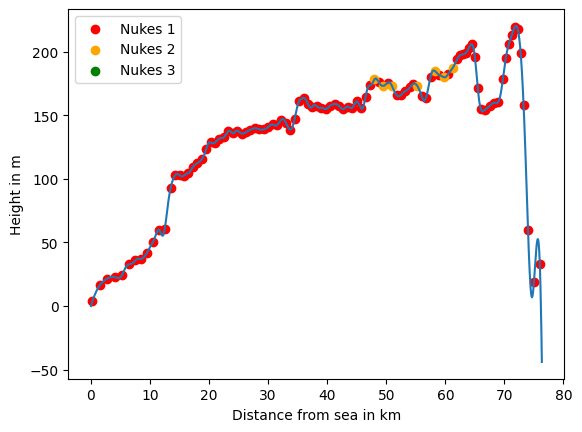

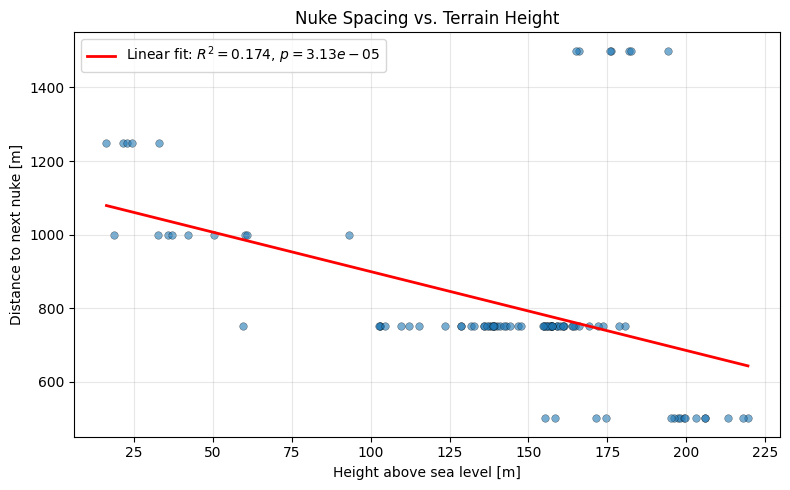

Slope:     -2.1452 m/m
Intercept: 1113.73 m
R²:        0.1743
p-value:   3.13e-05


In [38]:
objVal = 26254
nukes = [0 for _ in range(int(np.floor(distanceFromZero[-1])) // dist)]

with open("SettingsResults.txt", "r") as f:
    for line in f:
        data = line.split()
        idx = int(data[0])
        val = int(data[1])
        nukes[idx] = val

nukesX = [[] for _ in range(3)]
nukesY = [[] for _ in range(3)]
for i in range(len(nukes)):
    if nukes[i] != 0:
        nukesX[nukes[i]-1].append(i * dist)
        nukesY[nukes[i]-1].append(interpolator(i * dist).flatten()[0])

colors = ["red", "orange", "green"]
plt.figure()
plt.plot(x/1000, y)
for i in range(3):
    nx = np.array(nukesX[i])
    ny = np.array(nukesY[i])
    plt.scatter(nx/1000, ny, color=colors[i], label=f"Nukes {i+1}")
plt.xlabel("Distance from sea in km")
plt.ylabel("Height in m")
plt.legend()
plt.show()

plot_nuke_spacing_vs_height(nukesX[0], nukesY[0])